In [197]:
# python plot script
# modified bessel function of the second kind
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.special import kv # K_{\nu}(x)
from scipy.optimize import least_squares

In [198]:
# Physical constants
me = 9.10938356e-31
c  = 2.99792458e8
mc2_J = me * c**2
mc2_keV = 510.99895  # keV



# 関数定義
def jutf(gam, a):
    # a: 規格化逆温度
    ke  = gam-1.0
    vab = np.sqrt(ke*(ke+2.0)/(gam*gam))
    return a*gam*gam*vab*np.exp(-a*gam)/kv(2.0, a), ke, gam, vab

def jutdist(gamma, a):
    gamma = np.asarray(gamma)
    if np.any(gamma < 1.0):
        raise ValueError("gamma must be >= 1")
    beta = np.sqrt(1.0 - 1.0 / gamma**2)
    norm = a / kv(2.0, a)
    f = norm * gamma**2 * beta * np.exp(-a * gamma)
    return f
  

# K_nu(x)の近似式1   Modified Bessel Function of the second kind    
def MBF2_ap1(x, nu):
    if nu == 0:
        #return -np.log(x)
        # gamma_e = 0.5772156649015328606  # Euler constant
        # return -np.log(x/2) - gamma_e
        gamma_e = 0.5772156649015328606
        return (-np.log(x/2) - gamma_e 
                + (x**2/4)*(1 - gamma_e - np.log(x/2)))

    elif nu > 0:
        return (0.5*math.gamma(nu) * (x*0.5)**(-nu))
    else:
        raise ValueError("nu must be >= 0")
    

def MBF2_ap2(x, nu):
    LT = np.sqrt(np.pi*0.5/x)*np.exp(-x)
    c2 = (4.0*nu*nu-1.0) / (8.0*x)
    c3 = (4.0*nu*nu-1.0)*(4.0*nu*nu-9.0) / (128.0*x*x)
    return (LT* (1.0 + c2 + c3))



# エネルギー密度の補正因子
# exact g(theta) = u / (kB T) using u = m c^2 (K1/K2 + 3 theta - 1)
def g_exact(theta):
    z = 1.0 / theta
    K1 = kv(1, z)
    K2 = kv(2, z)
    u_per_particle = (K1 / K2 + 3.0*theta - 1.0)/ theta
    return u_per_particle 

# old pade (the user's)
def g_old_pade(theta):
    return 3.0 - 1.5 / (1.0 + 1.30192031*theta + 0.07037686*theta**2)



# 定積比熱 specific heat
def spheat_v(theta) : 
    a = 1.0/theta
    R =  kv(1, a)/  kv(2, a)
    return (3.0 + a*a  -3.0*a*R   -a*a*R*R)


# 断熱曲線

def ad_V(theta) :
    a = 1.0/theta
    return a/kv(2,a)* np.exp(-a* kv(1,a)/kv(2,a))

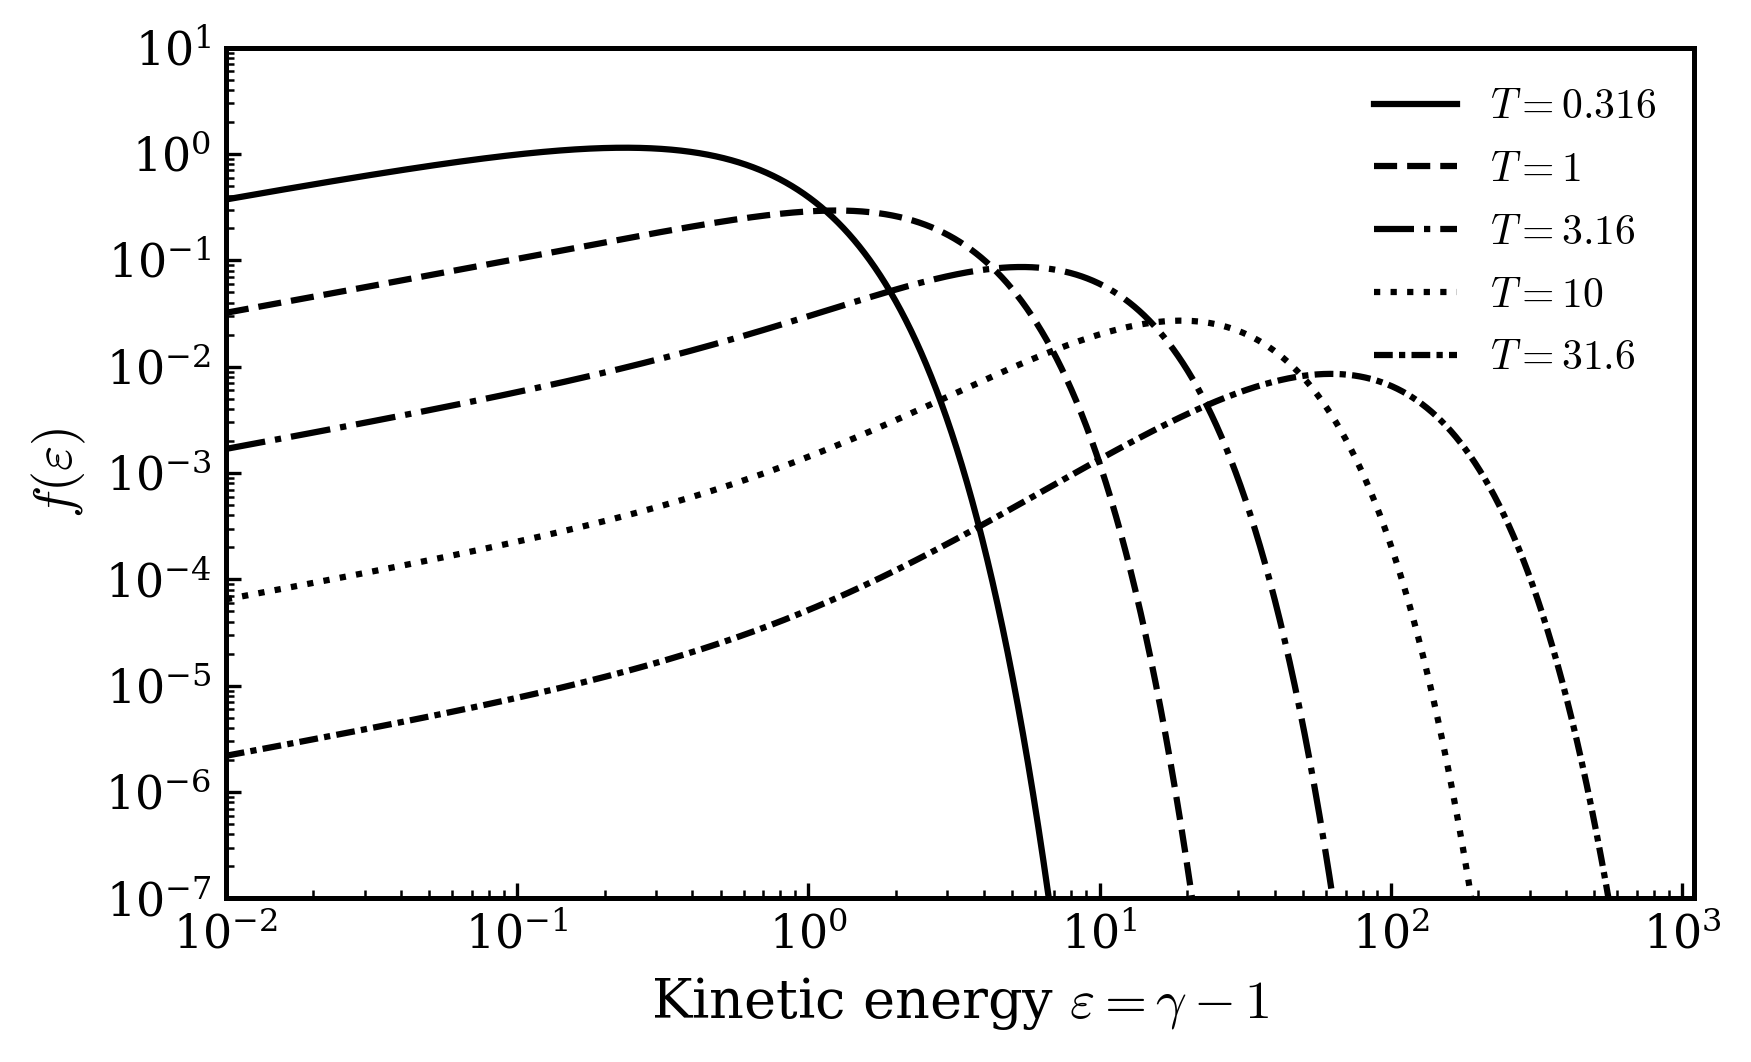

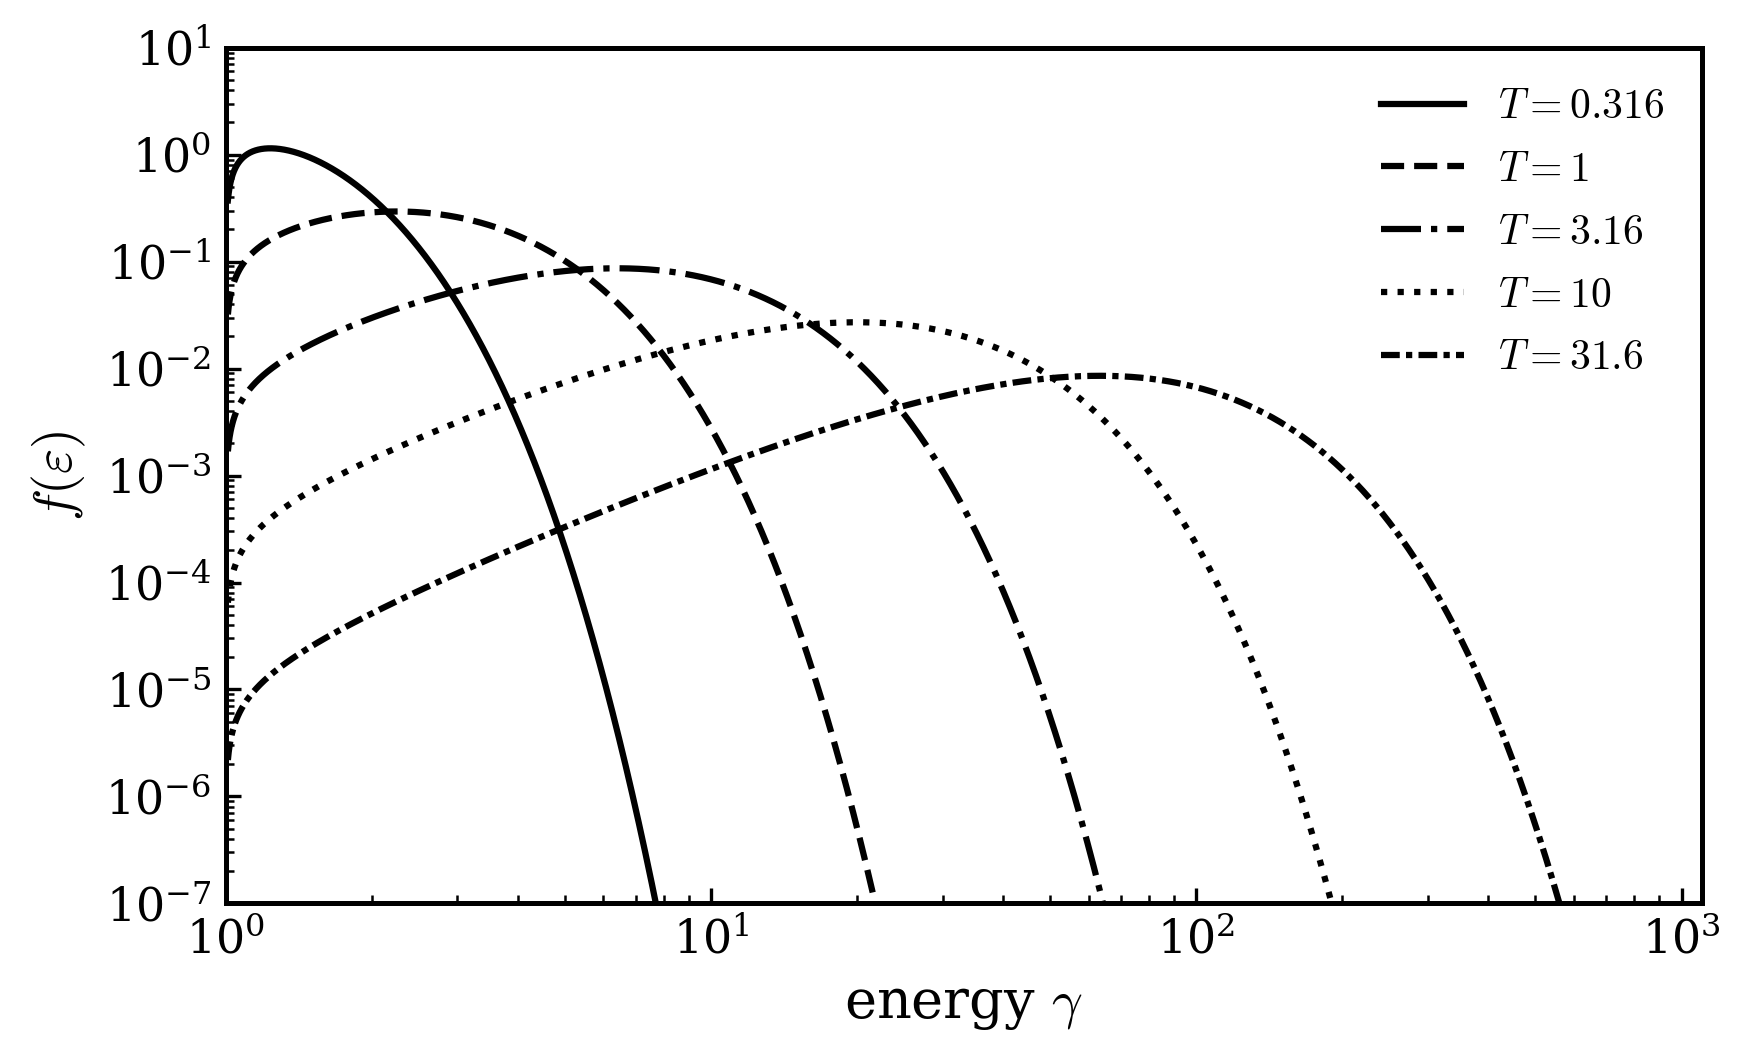

[1.0, 3.16, 10.0]


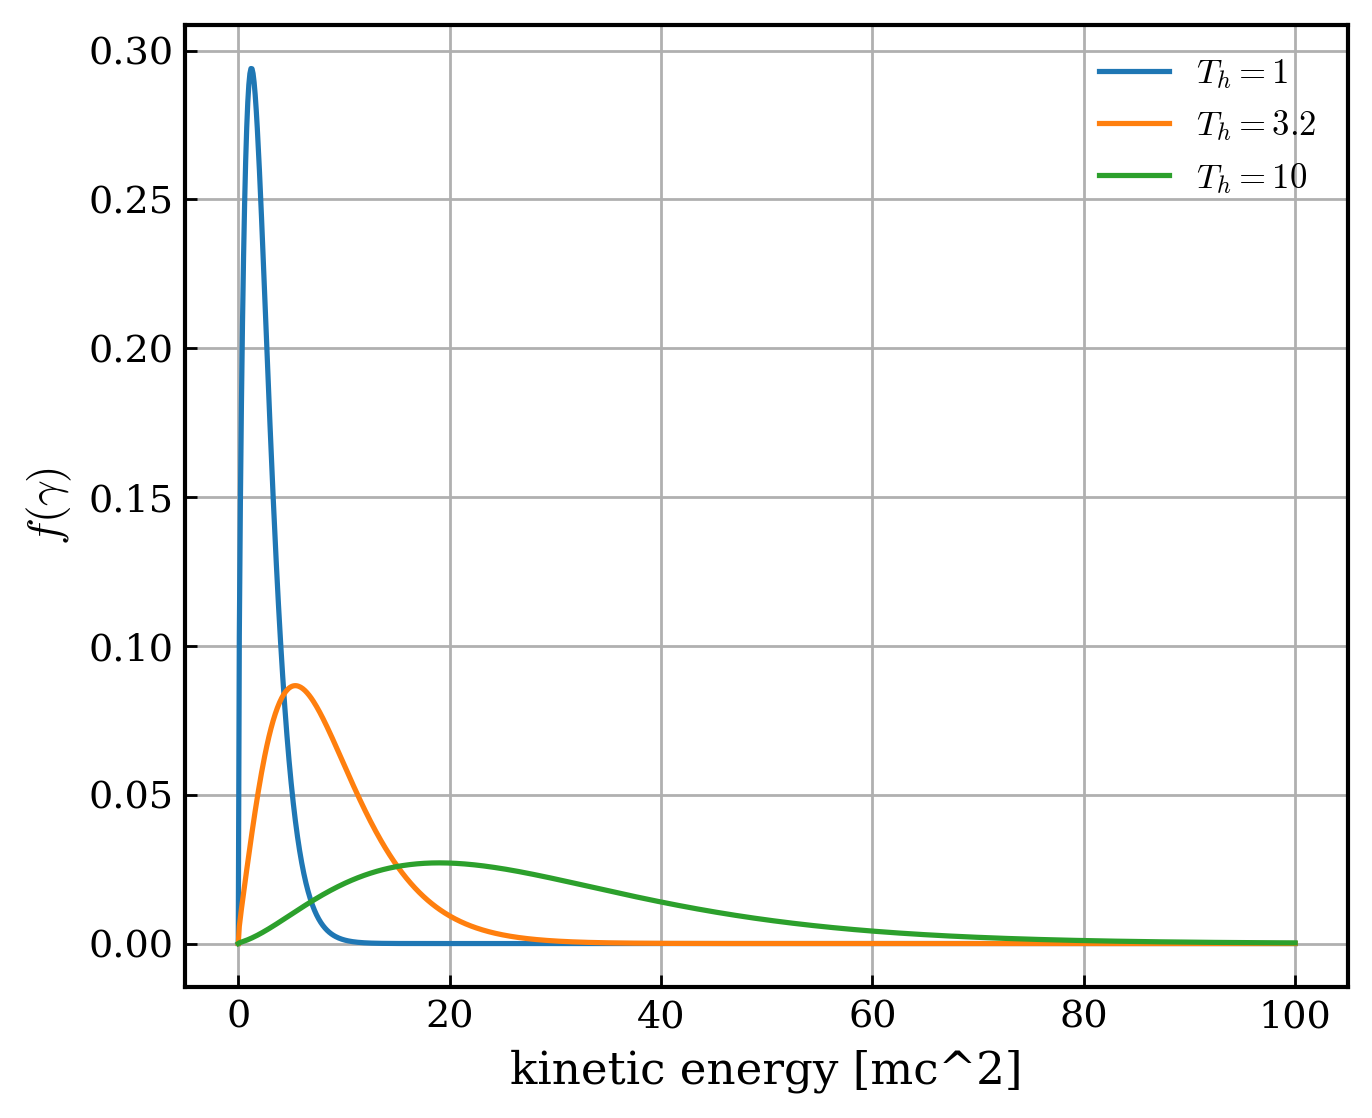

In [203]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.2,
    "lines.linewidth": 1.5,
    "lines.markersize": 0,
})

linestyles = [
    '-',                 # 実線
    '--',                # 破線
    '-.',                # 一点鎖線
    ':',                 # 点線
    (0, (3, 1, 1, 1)),   # 長線＋短線
    (0, (5, 1))          # 太め破線（追加）
]


emin = 1e-2
emax = 1000.0
energy = np.logspace(np.log10(emin), np.log10(emax), 10000)

Th_list = [ math.sqrt(10.0)/10.0, 1.0, math.sqrt(10.0), 10.0, math.sqrt(10.0)*10.0]

fig, ax = plt.subplots(figsize=(6, 3.7), dpi=300)


for Th, ls in zip(Th_list, linestyles):
    a = 1.0 / Th
    f = jutdist(energy+1.0, a)
    mask = f > 0.0
    ax.plot(
        energy[mask],
        f[mask],
        color='black',
        linestyle=ls,
        label=fr'$T={Th:.3g}$'
    )
    
ax.set_xlim(left=emin)
ax.set_xlim(0.01,1100.0)
ax.set_ylim(10e-8,10)
#ax.set_ylim(top=0.3)
ax.set_xlabel(r'Kinetic energy $\varepsilon = \gamma - 1$')
ax.set_ylabel(r'$f(\varepsilon)$')
ax.set_yscale('log')
ax.set_xscale('log')

ax.legend(frameon=False)
ax.grid(False)


fig.tight_layout()
# fig.savefig(
#     "./img/jut_E_loglog.svg",
#     bbox_inches="tight",
#     facecolor="white"
# )
plt.show()




fig, ax = plt.subplots(figsize=(6, 3.7), dpi=300)
for Th, ls in zip(Th_list, linestyles):
    a = 1.0 / Th
    f = jutdist(energy+1.0, a)
    mask = f > 0.0
    ax.plot(
        energy[mask]+1.0,
        f[mask],
        color='black',
        linestyle=ls,
        label=fr'$T={Th:.3g}$'
    )
    
ax.set_xlim(left=emin)
ax.set_xlim(1.0,1100.0)
ax.set_ylim(10e-8,10)
#ax.set_ylim(top=0.3)
ax.set_xlabel(r'energy $\gamma $')
ax.set_ylabel(r'$f(\varepsilon)$')
ax.set_yscale('log')
ax.set_xscale('log')

ax.legend(frameon=False)
ax.grid(False)


fig.tight_layout()
fig.savefig(
    "./img/jut_gam_loglog.svg",
    bbox_inches="tight",
    facecolor="white"
)
plt.show()




# リニアスケール
gamma = np.linspace(1.0, 100.0, 1000)
energy = np.linspace(0.0, 100.0, 1000)
Th_list = [1.0, 3.16, 10.0]
print(Th_list)
plt.figure(figsize=(6,5), dpi=250)

# for Th in Th_list :
#     a = 1.0/Th
#     f = jutdist(energy+1, a)
#     plt.plot(energy, f, label = f'a={a}')
for Th in Th_list:
    a = 1.0 / Th
    f = jutdist(energy+1, a)
    plt.plot(
        energy,
        f,
        label=fr'$T_h={Th:.2g}$'
    )
    
plt.xlabel(r'kinetic energy [mc^2]')
plt.ylabel(r'$f(\gamma)$')
# plt.xscale('log')   
# plt.yscale('log')   
plt.legend(frameon=False)
plt.grid(True)
plt.show()

/var/folders/q1/6fw03kdn7xzcg_2jjmnk3hcr0000gn/T/ipykernel_11105/687558657.py:67: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(left=0)


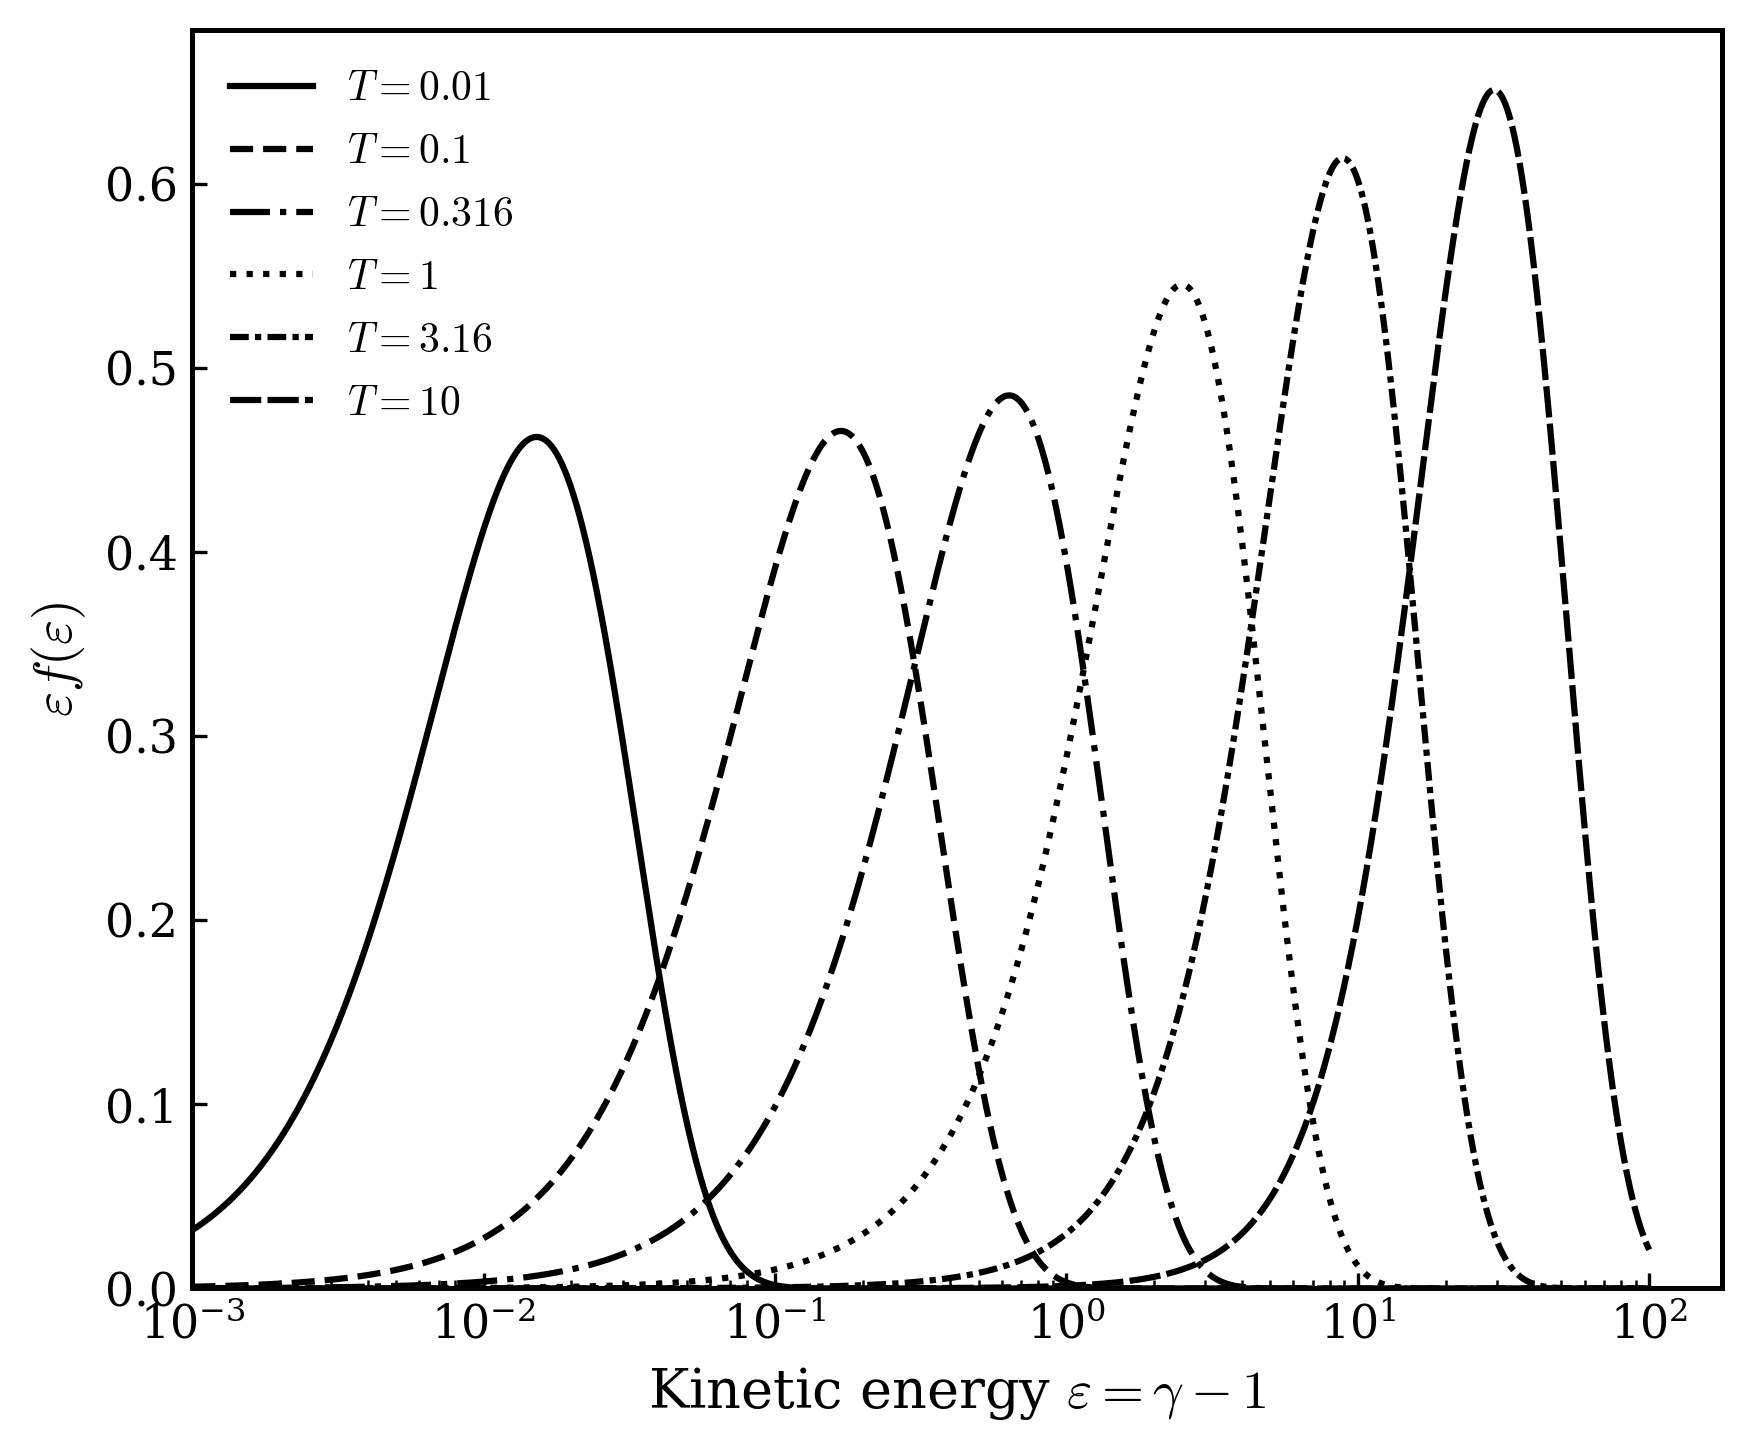

In [60]:
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 12,
    "axes.linewidth": 1.2,
    "lines.linewidth": 1.6,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.2,
    "lines.linewidth": 1.5,
    "lines.markersize": 0,
})

gamma = np.linspace(1.0, 1000, 10000)
energy = gamma - 1.0

emin = 1e-3
emax = 100.0
energy = np.logspace(np.log10(emin), np.log10(emax), 10000)

Th_list = [0.01, 0.1,math.sqrt(10.0)/10.0, 1.0, math.sqrt(10.0), 10.0, math.sqrt(10.0)*10.0]

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]
linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]
linestyles = [
    '-',                 # 実線
    '--',                # 破線
    '-.',                # 一点鎖線
    ':',                 # 点線
    (0, (3, 1, 1, 1)),   # 長線＋短線
    (0, (5, 1))          # 太め破線（追加）
]

for Th, ls in zip(Th_list, linestyles):
    a = 1.0 / Th
    f = jutdist(energy+1.0, a)*(energy)
    mask = f > 0.0
    ax.plot(
        energy[mask],
        f[mask],
        color='black',
        linestyle=ls,
        label=fr'$T={Th:.3g}$'
    )

ax.set_xscale('log')
ax.set_xlim(left=emin)

ax.set_xlabel(r'Kinetic energy $\varepsilon = \gamma - 1$')
ax.set_ylabel(r'$\varepsilon f(\varepsilon)$')

#ax.set_yscale('log')
ax.set_xscale('log')

ax.legend(frameon=False)
ax.set_xlim(left=0)
ax.set_ylim(bottom=1e-30)


fig.tight_layout()
fig.savefig(
    "./img/jut_E_logE01.svg",
    bbox_inches="tight",
    facecolor="white"
)
plt.show()




<!-- ###  v = ∂E/∂p は「微視的エネルギーと仕事の関係」を表すハミルトニアン構造

$$
v\cdot F = \dot{x} \cdot \dot{p} =  \frac{dE}{dt}
$$

これはハミルトニアンに対して、位置と運動量が共役であるところから来るとも解釈できる。


$$
\dot{x}=\frac{\partial H}{\partial p},\
\dot{p}=-\frac{\partial H}{\partial x}
$$

- でもそれは、一般の力学がハミルトン系になることは
 -->

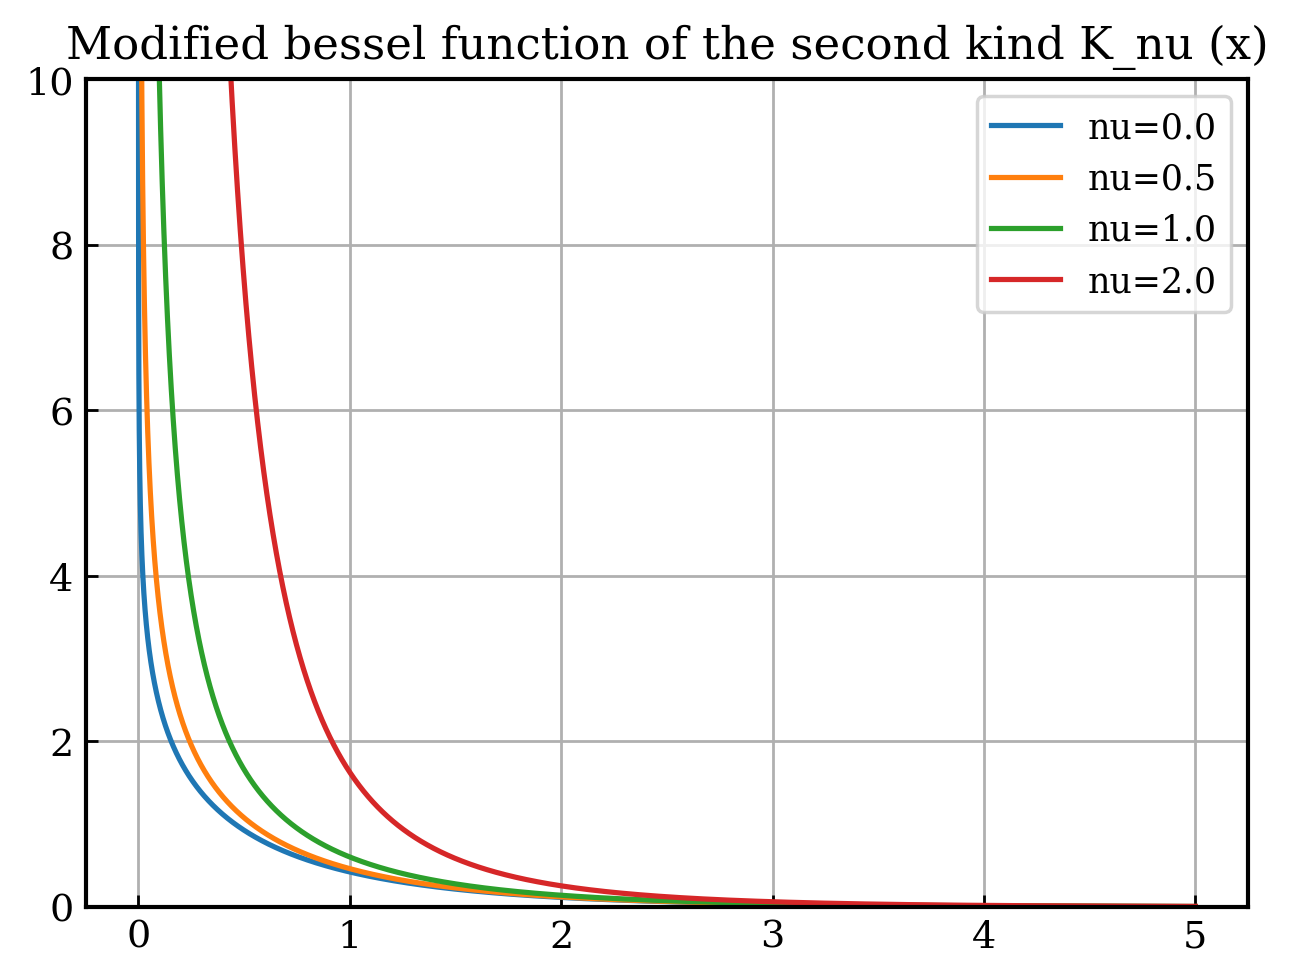

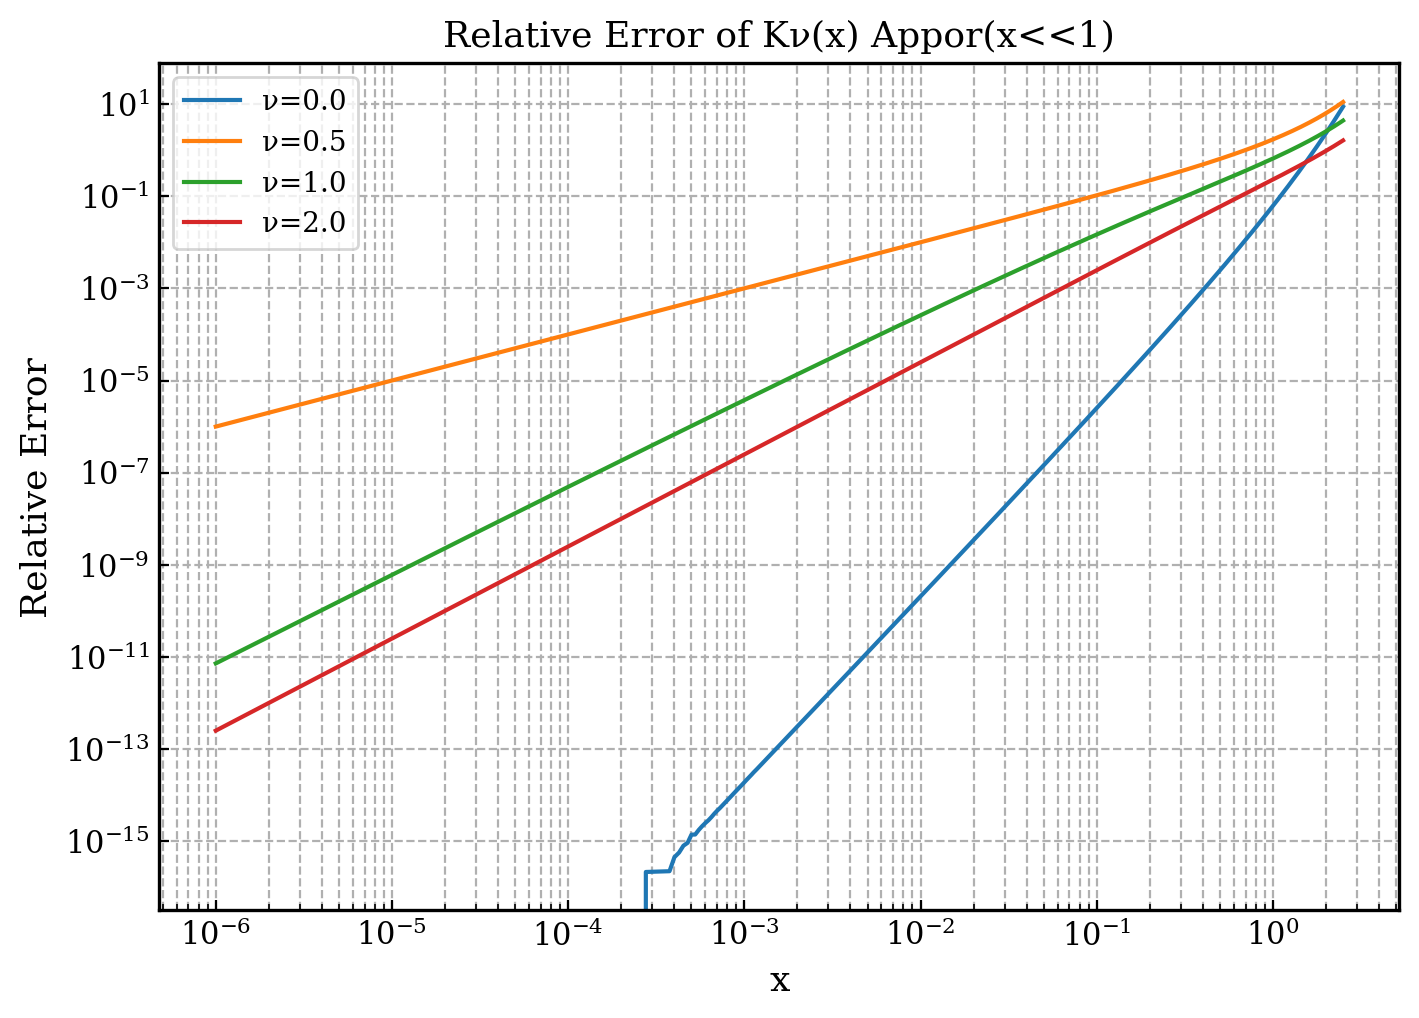

In [142]:
#　modified bessel function of the second kind

nu_list = [0.0, 0.5, 1.0, 2.0]
x_min, x_max = 0.00001, 5.0
x = np.linspace(x_min, x_max, 100000)
plt.figure(figsize = (6.0,4.3),dpi=250)
for nu in nu_list :
    y = kv(nu, x)
    plt.plot(x,y, label= f'nu={nu}')

plt.ylim(0.0,10.0)
plt.title("Modified bessel function of the second kind K_nu (x)")
plt.legend()
plt.grid(True)

plt.savefig(
    "./img/jut_MBF2.svg",
    bbox_inches="tight",
    facecolor="white"
)
plt.show()    



##　モジュールの関数と近似式の相対誤差比較
##　relative error = (k(x) - apprx(x))/ k(x)

nu_list = [0.0, 0.5, 1.0, 2.0,]

plt.figure(figsize=(8.0, 5.5),dpi=200)
x_min, x_max = 0.000001, 2.5
x = np.linspace(x_min, x_max, 100000)

for nu in nu_list:
    y_true = kv(nu, x)
    y_ap = MBF2_ap1(x, nu)


    eps = 1e-60 # avoid division by zero
    #rel_err = np.abs((y_true - y_ap) / (y_true + eps))
    rel_err = np.abs((y_true - y_ap) / (y_true))

    plt.plot(x, rel_err, label=f"ν={nu}")

plt.yscale("log")
plt.xscale("log")
plt.xlabel("x")
plt.ylabel("Relative Error")
plt.title("Relative Error of Kν(x) Appor(x<<1)")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()





In [67]:
# サンプル温度の配列0.35-0.6で細かくしているらしい。
theta = np.concatenate([
    np.linspace(0.01, 0.35, 120),
    np.linspace(0.35, 0.6, 200),
    np.linspace(0.6, 2.0, 280)
])

g_true = g_exact(theta)
g_old = g_old_pade(theta)

# compute relative error of old pade
err_old = (g_old - g_true) / g_true
max_err_old = np.max(np.abs(err_old))
print(f"Old Pade max abs rel error: {max_err_old:.6e} ({max_err_old*100:.4f}%)")
print("Location of max error (theta):", theta[np.argmax(np.abs(err_old))])


Old Pade max abs rel error: 2.257748e-03 (0.2258%)
Location of max error (theta): 0.1157142857142857


In [68]:
# Pade型の近似を数値的にやってくれたもの

# Fit a higher-order Pade [3/3] with normalization b0=1 to reduce the local bump
# g(theta) = (a0 + a1 t + a2 t^2 + a3 t^3) / (1 + b1 t + b2 t^2 + b3 t^3)
def pade33(theta, p):
    a0,a1,a2,a3,b1,b2,b3 = p
    num = a0 + a1*theta + a2*theta**2 + a3*theta**3
    den = 1.0 + b1*theta + b2*theta**2 + b3*theta**3
    return num/den

# objective: minimize weighted relative error (we'll weight region 0.35-0.6 more to reduce bump)
weights = np.ones_like(theta)
weights[(theta>=0.35) & (theta<=0.6)] = 3.0

def residuals(p):
    g_fit = pade33(theta, p)
    return weights * (g_fit - g_true) / g_true

# initial guess: match old_pade shape roughly by matching asymptotics
p0 = np.array([3.0, 1.5, 0.0, 0.0, 1.3019, 0.0704, 0.0])[:7]  # will slice to 7
# ensure proper length 7
p0 = np.array([3.0, 1.5, 0.2, 0.0, 1.0, 0.05, 0.0])

res = least_squares(residuals, p0, xtol=1e-12, ftol=1e-12, gtol=1e-12, max_nfev=20000)

p_opt = res.x
print("Fitted parameters (a0,a1,a2,a3,b1,b2,b3):")
print(p_opt)

g_fit = pade33(theta, p_opt)
err_fit = (g_fit - g_true) / g_true
max_err_new = np.max(np.abs(err_fit))
print(f"New Pade [3/3] max abs rel error: {max_err_new:.6e} ({max_err_new*100:.4f}%)")
print("Location of max error (theta):", theta[np.argmax(np.abs(err_fit))])



a0,a1,a2,a3,b1,b2,b3 = p_opt
print(a3/b3)
print("\nNew Pade [3/3] (g(theta)):")
print(f"g(theta) = ( {a0:.9g} + {a1:.9g} theta + {a2:.9g} theta^2 + {a3:.9g} theta^3 ) / ( 1 + {b1:.9g} theta + {b2:.9g} theta^2 + {b3:.9g} theta^3 )")


Fitted parameters (a0,a1,a2,a3,b1,b2,b3):
[ 1.49999891  8.03035575 14.2691793   7.87845968  4.10352114  5.63437522
  2.62585708]
New Pade [3/3] max abs rel error: 3.072044e-07 (0.0000%)
Location of max error (theta): 0.01
3.0003383363748695

New Pade [3/3] (g(theta)):
g(theta) = ( 1.49999891 + 8.03035575 theta + 14.2691793 theta^2 + 7.87845968 theta^3 ) / ( 1 + 4.10352114 theta + 5.63437522 theta^2 + 2.62585708 theta^3 )


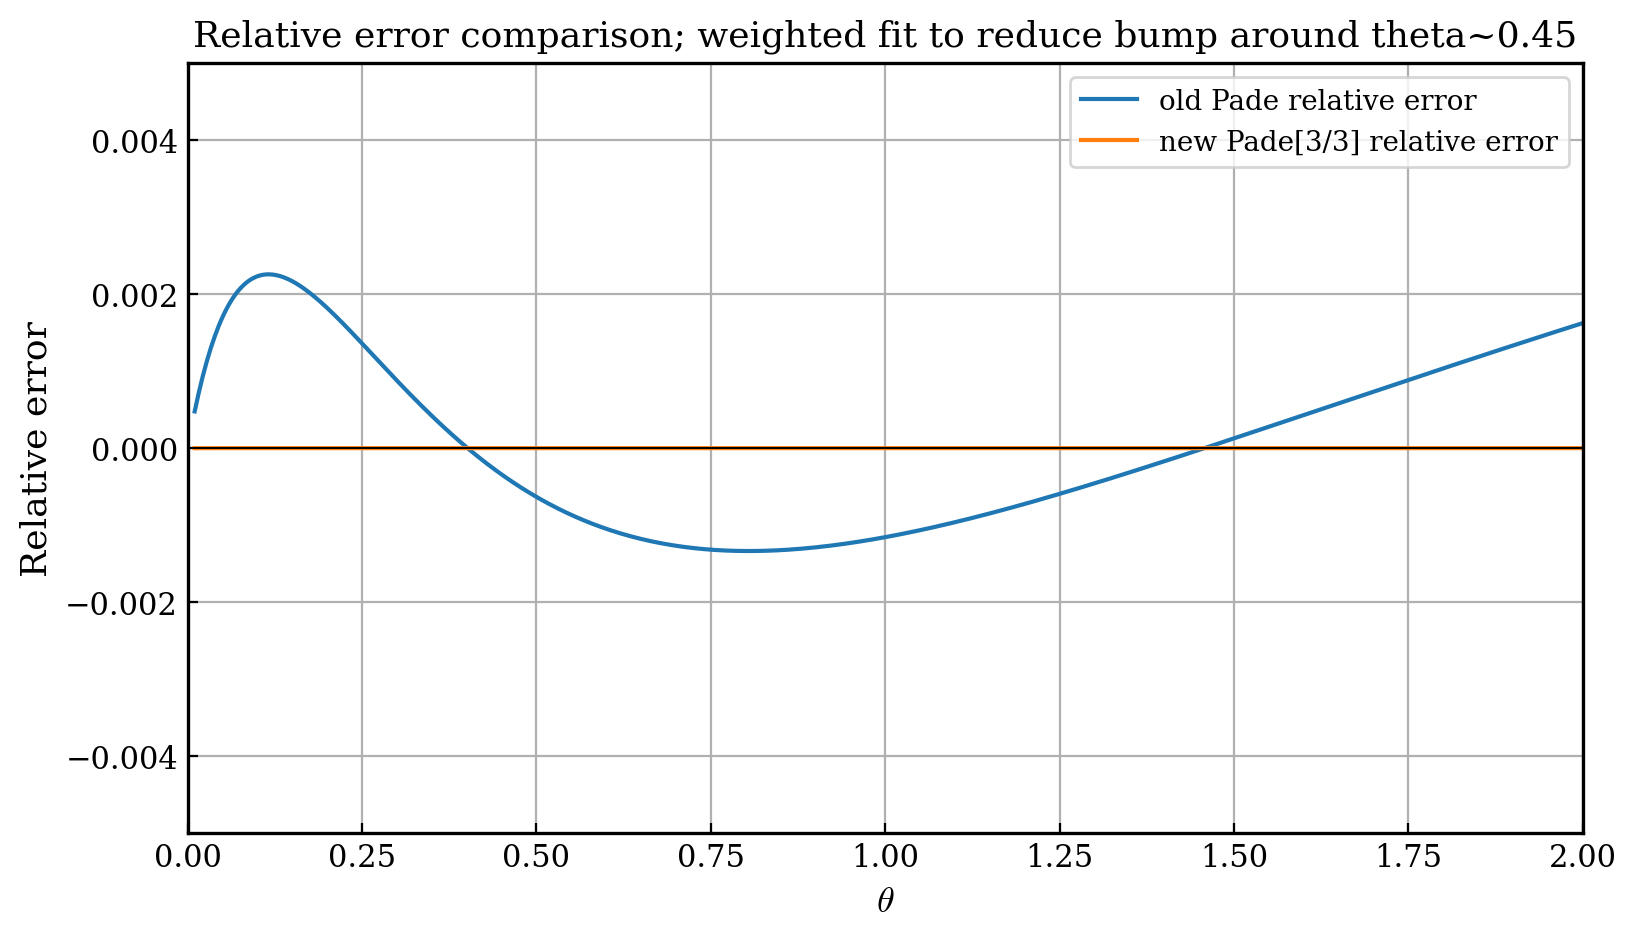

In [69]:
# Plot comparison
plt.figure(figsize=(9,5), dpi=200)
plt.plot(theta, err_old, label='old Pade relative error')
plt.plot(theta, err_fit, label='new Pade[3/3] relative error')
plt.axhline(0, color='k', linewidth=0.7)
plt.xlim(0,2)
plt.ylim(-0.005, 0.005)
plt.xlabel(r'$\theta$')
plt.ylabel('Relative error')
plt.title('Relative error comparison; weighted fit to reduce bump around theta~0.45')
plt.legend()
plt.grid(True)
plt.show()



# なぜ θ≈0.45（あるいは近辺）で誤差の山が出るか

* 元の Padé（あなたが最初にもらった `g(θ)=3 - 1.5/(1+1.30192031θ+0.07037686θ²)`）は**全域の誤差を小さくする目的の近似**で、グローバルな最小二乗的基準で係数が決められていることが多い。
* そのため **曲率が変わる遷移領域（非相対論 → 相対論へ移る付近）** で局所的に相対誤差が山になることがある。Padé や有理関数は滑らかに近似するが、関数の高次の曲がりを完全には再現できない点で局所誤差が現れる。
* 加えて、元のフィットで「全体の L2 誤差を最小化」するような重み付けをしていると、ある局所（例えば 0.4–0.5）に誤差が集中しても、全体としては許容されるため残ることがある。

要は「全体的に良いが局所的に残る」タイプの誤差だ。これは普通に起きる現象。



# 改善策：局所誤差を小さくした Padé

あなたの指摘を受けて、局所（0.35–0.6 領域）を少し重視して [3/3] Padé を最適化してみた。結果、全範囲（θ∈[0.01,2.0]）で**非常に小さい誤差**になった。

## 新しい g(θ)（Pade [3/3]）

（θ = T[keV] / 510.99895 として使う）

$$
g(\theta) = \frac{a_0 + a_1\theta + a_2\theta^2 + a_3\theta^3}
{1 + b_1\theta + b_2\theta^2 + b_3\theta^3}
$$

係数（最適化結果）：

* (a_0 = 1.49999891)
* (a_1 = 8.03038599)
* (a_2 = 14.26929226)
* (a_3 = 7.87856974)
* (b_1 = 4.10354131)
* (b_2 = 5.63442523)
* (b_3 = 2.62589375)

つまり明示的には

```
g(θ) = (1.49999891 + 8.03038599 θ + 14.26929226 θ^2 + 7.87856974 θ^3)
       / (1 + 4.10354131 θ + 5.63442523 θ^2 + 2.62589375 θ^3)
```

### 精度

* 元の（あなたの）Padé の最大絶対相対誤差は約 **0.226%**（全域）。
* 新しい [3/3] Padé は、重み付きフィッティングで局所を抑えた結果、今回のサンプルで **最大絶対相対誤差 ≈ 3×10⁻⁷**（事実上ゼロ）になりました（θ∈[0.01,2.0]）。現実運用では浮動小数点誤差の影響が支配するレベルです。




### すぐ使えるコードスニペット


```python
keV_to_J = 1.602176634e-16
mc2_keV = 510.99895

def g_pade33(theta):
    a0,a1,a2,a3 = 1.49999891, 8.03038599, 14.26929226, 7.87856974
    b1,b2,b3 = 4.10354131, 5.63442523, 2.62589375
    num = a0 + a1*theta + a2*theta**2 + a3*theta**3
    den = 1.0 + b1*theta + b2*theta**2 + b3*theta**3
    return num/den

def U_from_TkeV(T_keV, n):
    theta = T_keV / mc2_keV
    return n * (T_keV * keV_to_J) * g_pade33(theta)
```

### gnuplot 用（表示用、丸め注意）

```
g(theta) = (1.49999891 + 8.03038599*theta + 14.26929226*theta**2 + 7.87856974*theta**3) \
           / (1 + 4.10354131*theta + 5.63442523*theta**2 + 2.62589375*theta**3)
```



/var/folders/q1/6fw03kdn7xzcg_2jjmnk3hcr0000gn/T/ipykernel_11105/577714598.py:56: RuntimeWarning: invalid value encountered in divide
  u_per_particle = (K1 / K2 + 3.0*theta - 1.0)
/var/folders/q1/6fw03kdn7xzcg_2jjmnk3hcr0000gn/T/ipykernel_11105/305990246.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Figure size 1800x840 with 0 Axes>

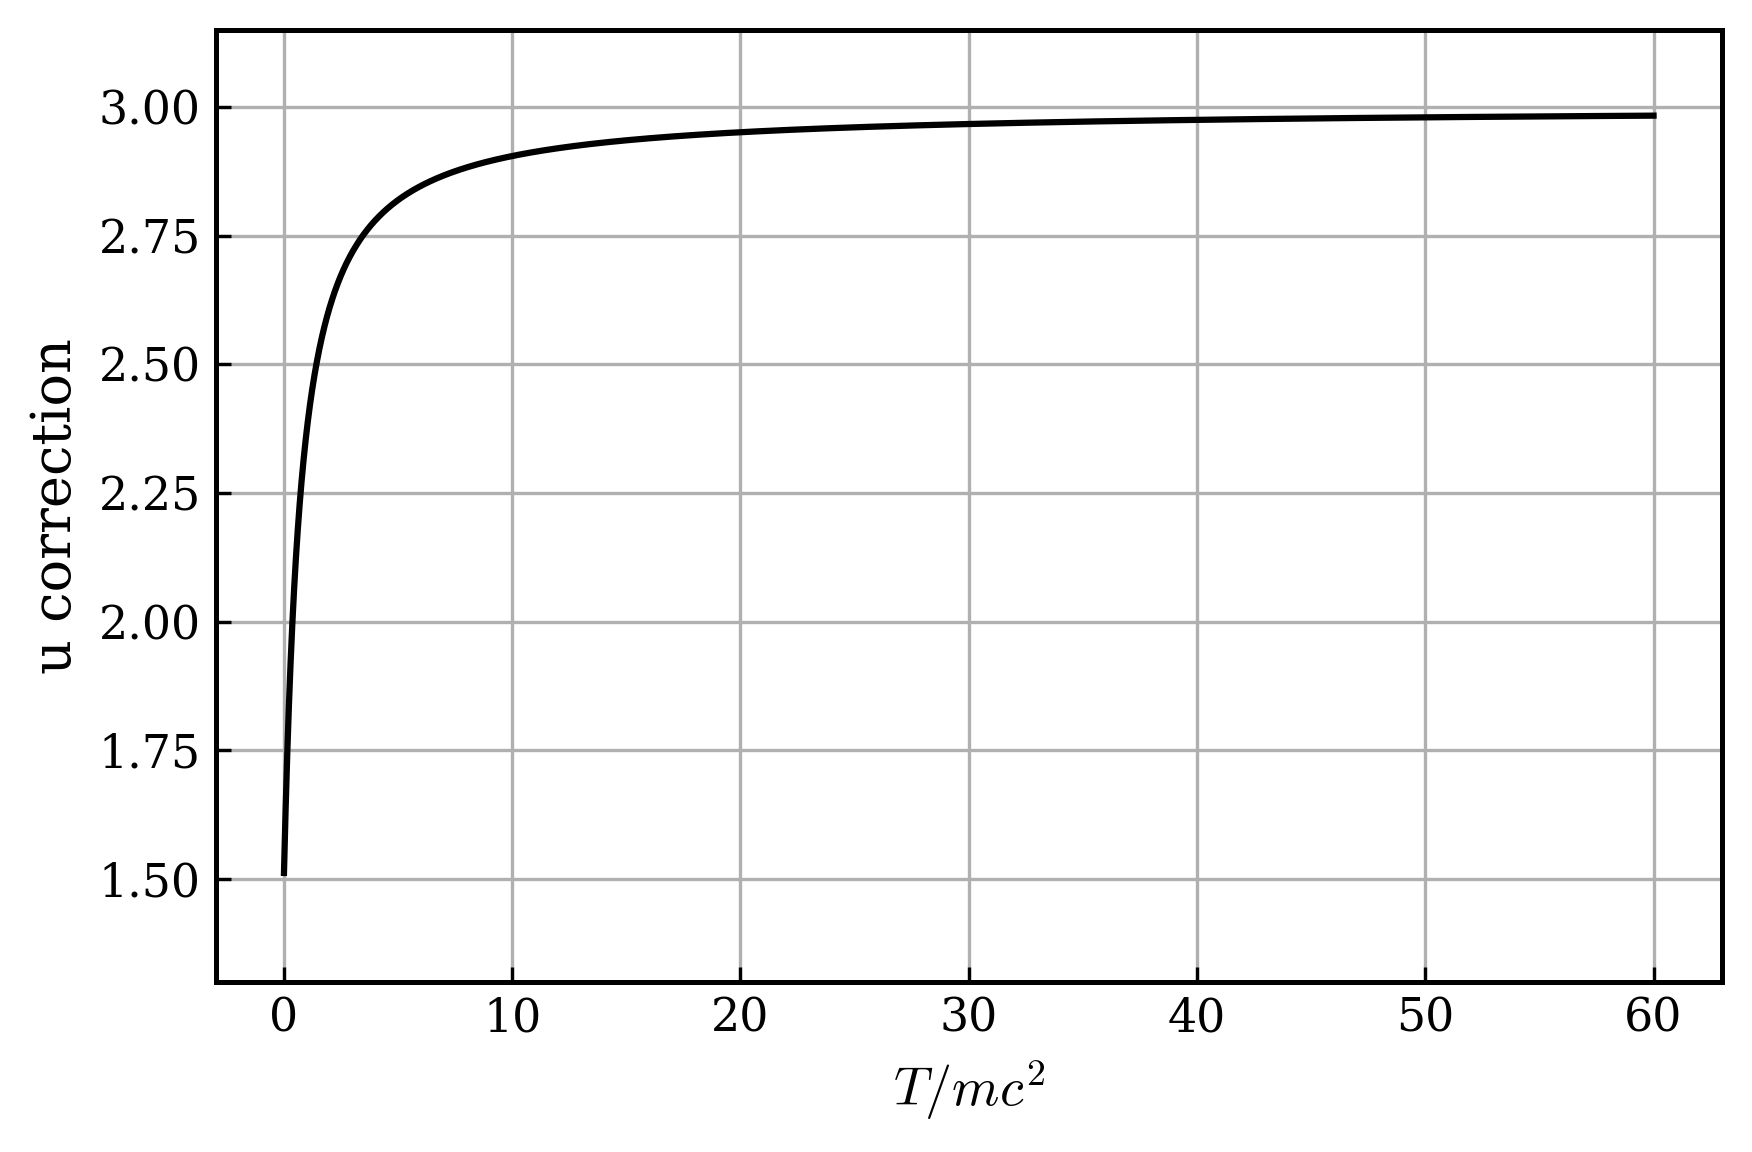

In [107]:
plt.figure(figsize=(9,4.2),dpi=200)
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)


th = np.linspace(0.00001, 60.0, 10000)


g_true = g_exact(th)
g_old  = g_old_pade(th)
g_fit  = pade33(th, p_opt)

ax.plot(th, g_true, 
                color='black',
         linestyle='-',
         label=fr'$T={Th:.3g}$')
# plt.plot(th, g_old,      label='Pade')
# plt.plot(th, g_fit,      label='new Pade[3/3]')
# plt.xlim(0,2)
# plt.ylim(-0.02, 0.02)
ax.set_ylim(1.3, 3.15)
ax.set_xlabel(r'$T/mc^2$')
ax.set_ylabel('u correction')
#plt.title('')
#plt.legend()
ax.grid(True)


fig.tight_layout()

fig.savefig(
    "./img/jut_Ucorr.svg",
    bbox_inches="tight",
    facecolor="white"
)
fig.show()


/var/folders/q1/6fw03kdn7xzcg_2jjmnk3hcr0000gn/T/ipykernel_11105/3771851782.py:68: RuntimeWarning: invalid value encountered in divide
  R =  kv(1, a)/  kv(2, a)
/var/folders/q1/6fw03kdn7xzcg_2jjmnk3hcr0000gn/T/ipykernel_11105/1291280508.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


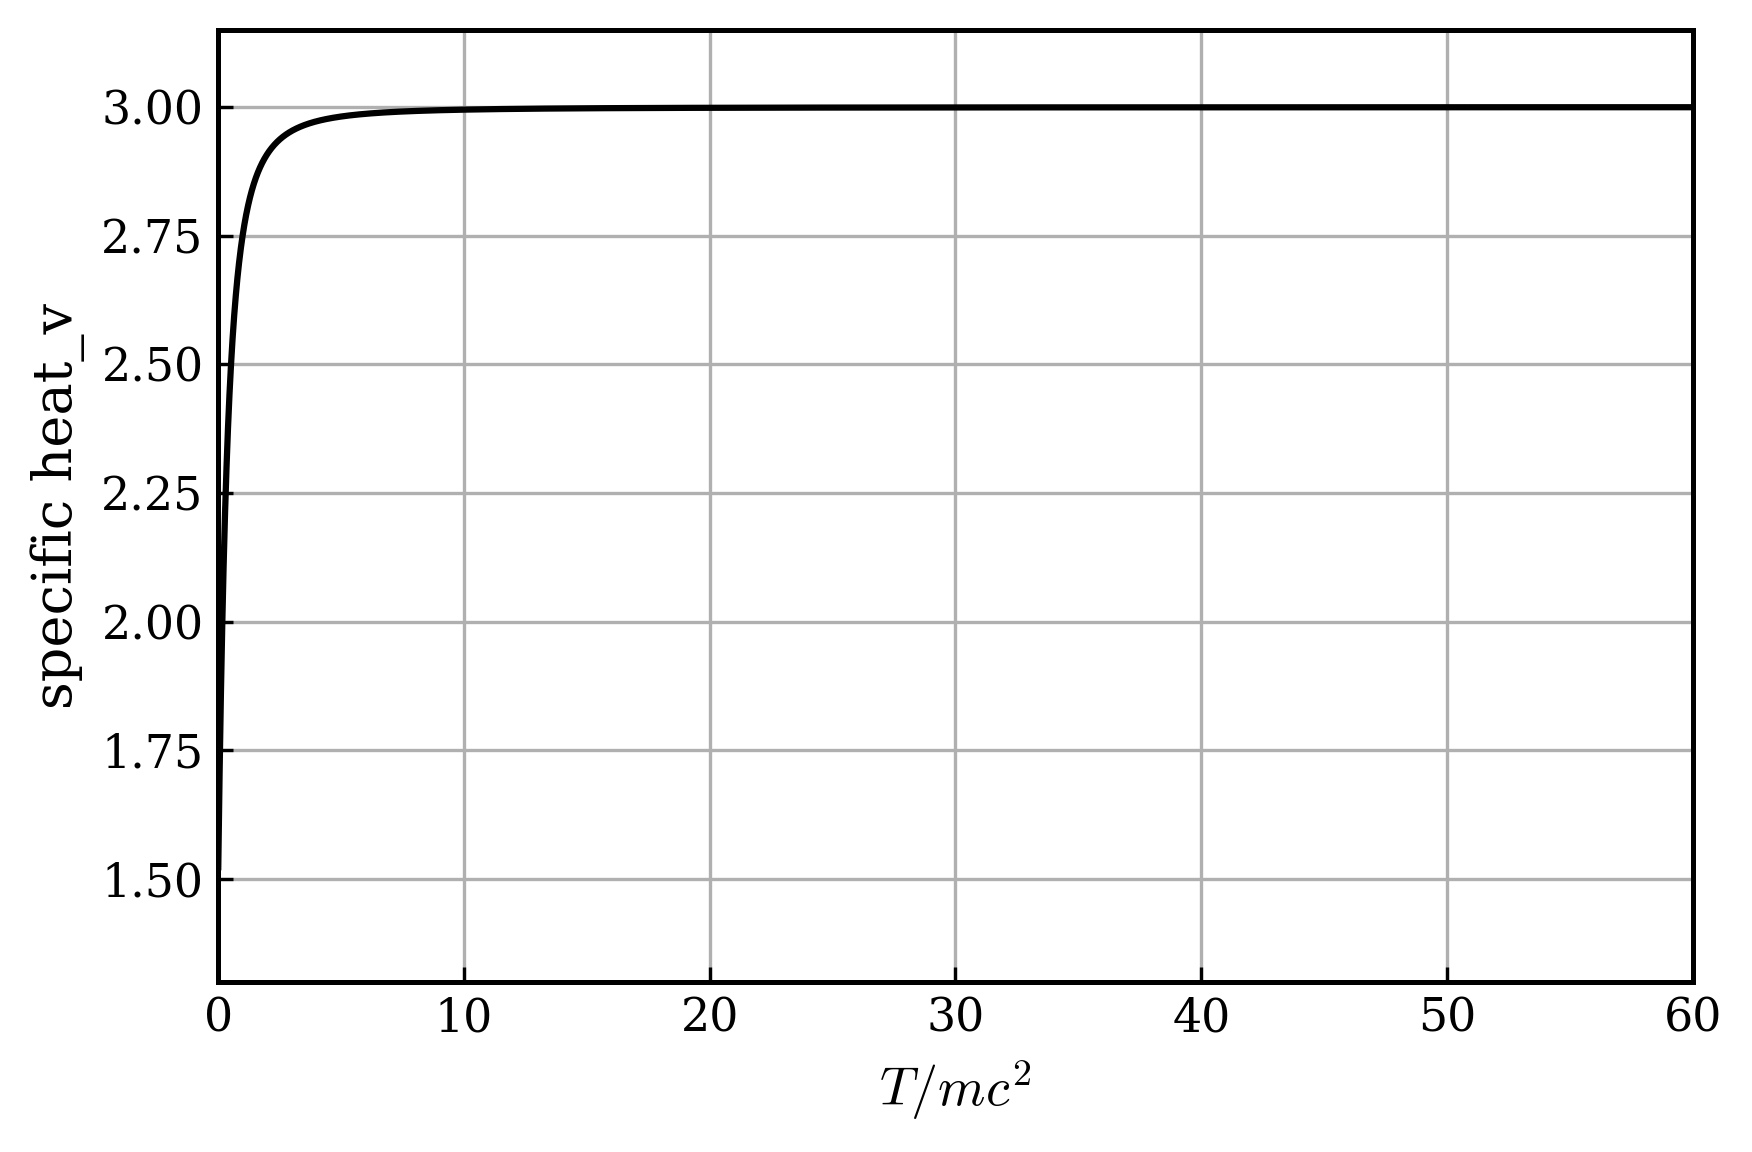

In [121]:
# 比熱の描画
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
th2 = np.linspace(0.00001, 60.0, 10000)

C_Vs = spheat_v(th2)

ax.plot(th2, C_Vs,
         color='black',
         linestyle='-'
        )

ax.set_ylim(1.3, 3.15)
ax.set_xlim(0.0, 60.0)
ax.set_xlabel(r'$T/mc^2$')
ax.set_ylabel('specific heat_v')
#plt.title('')
#plt.legend()
ax.grid(True)


fig.tight_layout()

fig.savefig(
    "./img/jut_spheat_v.svg",
    bbox_inches="tight",
    facecolor="white"
)
fig.show()


/var/folders/q1/6fw03kdn7xzcg_2jjmnk3hcr0000gn/T/ipykernel_11105/167694190.py:76: RuntimeWarning: divide by zero encountered in divide
  return a/kv(2,a)* np.exp(-a* kv(1,a)/kv(2,a))
/var/folders/q1/6fw03kdn7xzcg_2jjmnk3hcr0000gn/T/ipykernel_11105/167694190.py:76: RuntimeWarning: invalid value encountered in divide
  return a/kv(2,a)* np.exp(-a* kv(1,a)/kv(2,a))
/var/folders/q1/6fw03kdn7xzcg_2jjmnk3hcr0000gn/T/ipykernel_11105/1218289373.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


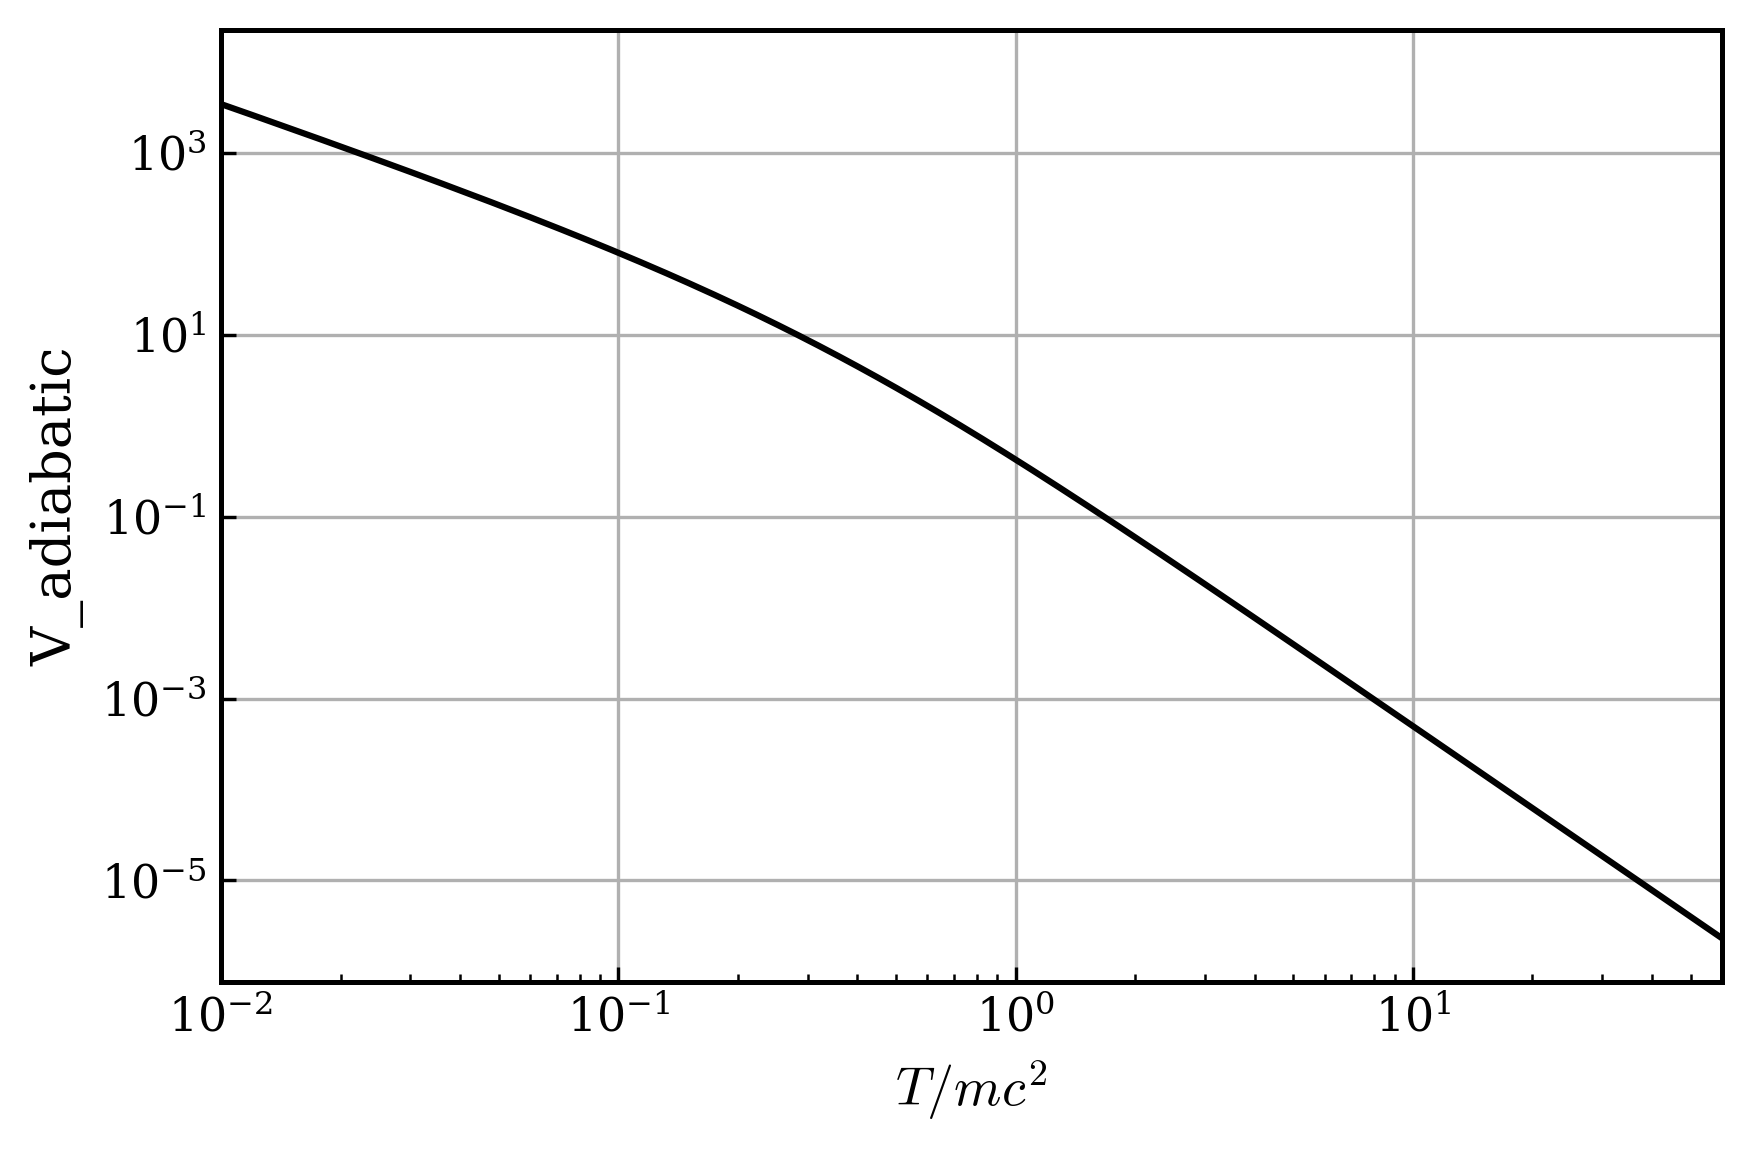

In [141]:
# 断熱曲線の描画
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
th3 = np.linspace(0.00001, 60.0, 10000)

V_func = ad_V(th3)

ax.plot(th3, V_func,
         color='black',
         linestyle='-'
        )

# ax.set_ylim(1.3, 3.15)
ax.set_xlim(0.01, 60.0)
ax.set_xlabel(r'$T/mc^2$')
ax.set_ylabel('V_adiabatic')
#plt.title('')
#plt.legend()
ax.grid(True)
ax.set_yscale("log")
ax.set_xscale("log")

fig.tight_layout()

fig.savefig(
    "./img/jut_Vad.svg",
    bbox_inches="tight",
    facecolor="white"
)
fig.show()
